## 13. Error Analysis-----------------------------------------------------------

Top Confused Class Pairs (Test Set):
 True Class  Predicted As  Count
          1             2   2294
          2             1   1489
          2             3    228
          2             5    206
          6             3    205
          2             6    189
          1             7    174
          3             6    173
          5             2    158
          7             1    122
          3             2     60
          3             4     46
          4             3     43
          6             2     38
          2             7     31


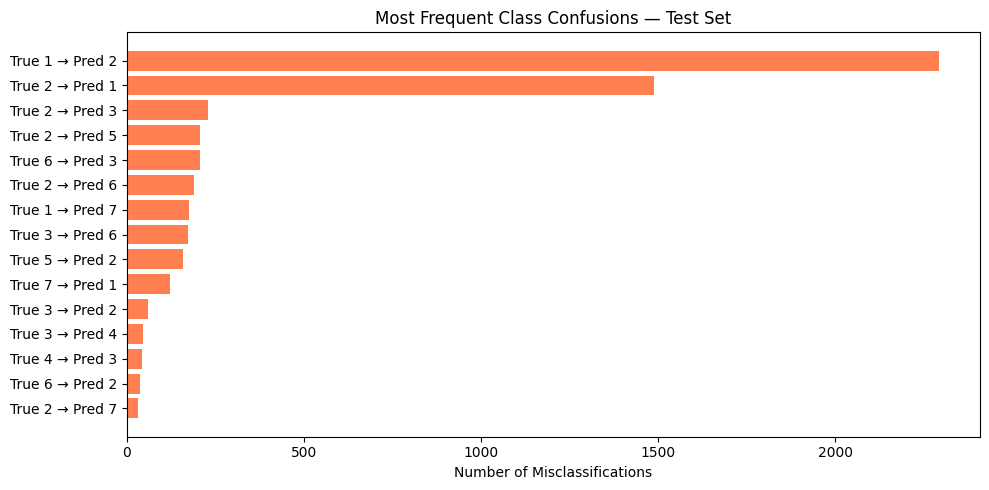

In [ ]:
# Build confusion matrix for the test set to identify misclassification patterns
cm_test = confusion_matrix(y_test, y_test_pred)
labels  = sorted(y_test.unique())

# Extract all off-diagonal entries (true and predicted class)
cm_df = pd.DataFrame(cm_test, index=labels, columns=labels)

confused_pairs = []
for i, true_lbl in enumerate(labels):
    for j, pred_lbl in enumerate(labels):
        if i != j and cm_test[i, j] > 0:
            confused_pairs.append({
                'True Class': true_lbl,
                'Predicted As': pred_lbl,
                'Count': cm_test[i, j]
            })

# sort by count to find the most problematic class pairs
confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(15)
print("Top Confused Class Pairs (Test Set):")
print(confused_df.to_string(index=False))

# visualize the top confused pairs as a horizontal bar chart
plt.figure(figsize=(10, 5))
confused_df['Pair'] = 'True ' + confused_df['True Class'].astype(str) + \
                      ' \u2192 Pred ' + confused_df['Predicted As'].astype(str)
plt.barh(confused_df['Pair'], confused_df['Count'], color='coral')
plt.gca().invert_yaxis()
plt.xlabel('Number of Misclassifications')
plt.title('Most Frequent Class Confusions \u2014 Test Set')
plt.tight_layout()
plt.show()

Based on the confusion matrix and the forest cover type domain:

Most commonly confused pairs tend to be:
- Class 1 (Spruce/Fir) and Class 2 (Lodgepole Pine): These two are the dominant classes and share overlapping elevation ranges and soil types, making them hard to separate even for tree experts.
- Class 3 (Ponderosa Pine) and Class 6 (Douglas Fir): Both occupy lower elevation zones with similar slope characteristics in Wilderness Area 2.
- Class 4 (Cottonwood/Willow) and Class 5 (Aspen): These minority classes have very few training samples, leading to high misclassification rates despite SMOTE.

Possible reasons for confusion:
1. Ecological overlap: Species that share similar elevation, soil, and hydrological conditions are naturally harder to distinguish from remotely sensed data alone.
2. Class imbalance residual: Even after SMOTE/resampling, synthetic minority samples may not fully capture real-world feature variability.
3. Binary wilderness/soil features: The one-hot encoding of soil types collapses nuanced soil chemistry into 40 binary columns, potentially losing fine-grained distinctions.
4. Missing temporal/spectral data: The dataset lacks vegetation indices or seasonal imagery that would help separate species phenologically.

## 14. Final Summary------------------------------------------------------------

In [ ]:
# Print the complete model comparison summary and test set results for the best model
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY (Validation Set)")
print("="*60)
print(summary_df.round(4).to_string())

print(f"\n>>> Best Model: {best_model_name}")
print(f"    Test Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test F1 Macro         : {f1_score(y_test, y_test_pred, average='macro'):.4f}")

# Report seed stability for the top two candidates
print(f"\nMultiple-seed stability (on validation):")
print(f"  SMOTE + RF  Avg F1: {np.mean(seed_f1_smote_rf):.4f} \u00b1 {np.std(seed_f1_smote_rf):.4f}")

FINAL MODEL COMPARISON SUMMARY (Validation Set)
                                Accuracy  Balanced Accuracy  F1 Macro
Model                                                                
SMOTE + Random Forest             0.9507             0.9362    0.9256
Cost-Sensitive Random Forest      0.9471             0.9153    0.9183
Random Forest (Baseline)          0.9483             0.8989    0.9166
Cost-Sensitive Decision Tree      0.9322             0.8919    0.8938
SMOTE + Decision Tree             0.9290             0.9086    0.8938
Decision Tree (Baseline)          0.9302             0.8900    0.8873
Balanced Random Forest            0.7915             0.8887    0.7270
Logistic Regression (Baseline)    0.7238             0.5132    0.5336
XGBoost (Baseline)                0.0393             0.0313    0.0139
Cost-Sensitive XGBoost            0.0351             0.0181    0.0113
SMOTE + XGBoost                   0.0211             0.0152    0.0073

>>> Best Model: SMOTE + Random Forest
   